# Module 4 — Pipeline NLP
**Eco-Smart Classifier | Personne 3**

Objectif : Classifier les déchets à partir de la colonne textuelle `Rapport_Collecte`.

Plan :
1. Chargement et exploration du texte
2. Prétraitement NLP (ZONE ROUGE — sans IA)
3. Comparaison de 4 vectorisations : BoW · TF-IDF · Word2Vec · FastText
4. Comparaison de 4 classifieurs : Naive Bayes · Logistic · SVM · Random Forest
5. Analyse des erreurs et matrice de confusion
6. Logging MLflow
7. Sauvegarde du meilleur modèle

In [24]:
import warnings
warnings.filterwarnings('ignore')

import re
import string
import pickle
import json
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
import yaml

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.model_selection import cross_val_score

with open('../params.yaml') as f:
    PARAMS = yaml.safe_load(f)

RANDOM_STATE = PARAMS['data']['random_state']
TEXT_COL     = PARAMS['columns']['text']
TARGET_COL   = PARAMS['columns']['target']

print('Params loaded. Random state:', RANDOM_STATE)

Params loaded. Random state: 42


## 1. Chargement des données

In [25]:
train_df = pd.read_csv('../data/processed/train.csv').dropna(subset=[TARGET_COL])
val_df   = pd.read_csv('../data/processed/val.csv').dropna(subset=[TARGET_COL])
test_df  = pd.read_csv('../data/processed/test.csv').dropna(subset=[TARGET_COL])

print(f'Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}')
print('\nDistribution (train):')
print(train_df[TARGET_COL].value_counts())

Train: 6,990 | Val: 1,498 | Test: 1,498

Distribution (train):
Categorie
Plastique    1956
Verre        1810
Papier       1623
Métal        1601
Name: count, dtype: int64


In [26]:
# Aperçu du texte brut
for cat in train_df[TARGET_COL].unique():
    sample = train_df[train_df[TARGET_COL] == cat][TEXT_COL].iloc[0]
    print(f'[{cat}]  {sample[:120]}\n')

[Verre]  Déchet en verre collecté en provenance de l'Usine A. Poids lourd : 251.7 kg, volume 491.3 L. Très rigide, non conducteur

[Métal]  Ferraille ou métal collecté issu de la collecte citoyenne. Masse 54.8 kg. Haute conductivité électrique, matériau extrêm

[Plastique]  Déchet plastique collecté depuis l'Usine B. Poids 21.6 kg, volume 51.4 L. Rigidité rigide, non conducteur. Surface légèr

[Papier]  Déchet de type papier identifié à l'Usine B. Volume estimé 24.3 L, poids 12.8 kg. Texture semi-rigide, très opaque.



## 2. Prétraitement NLP
> **ZONE ROUGE** — implémentation manuelle, sans assistance IA.

In [27]:
# ── Stopwords français + domaine ─────────────────────────────────────────────
FRENCH_STOPWORDS = {
    'le','la','les','de','du','des','un','une','et','en',
    'au','aux','à','par','pour','sur','avec','dans','est',
    'sont','ont','a','il','elle','ils','elles','nous','vous',
    'je','tu','se','si','ou','mais','car','que','qui','dont',
    'où','ne','pas','plus','très','bien','tout','tous','cette',
    'ce','ces','cet','mon','ton','son','ma','ta','sa','même',
    'lors','via','non',
}

DOMAIN_STOPWORDS = {
    'lot','collecte','collecté','récupéré','provenance','matériau',
    'état','général','poids','volume','type','identifié','renseigné',
    'site','kg','litre','aspect','bon','moyen','léger','masse','totale',
    'estimé','mesuré','total','autres',
}

ALL_STOPWORDS = FRENCH_STOPWORDS | DOMAIN_STOPWORDS
print(f'Stopwords : {len(FRENCH_STOPWORDS)} français + {len(DOMAIN_STOPWORDS)} domaine = {len(ALL_STOPWORDS)} total')

Stopwords : 60 français + 26 domaine = 86 total


In [28]:
def clean_text(text: str) -> str:
    """Minuscules, suppression chiffres+unités, ponctuation."""
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'\d+[.,]?\d*\s*(kg|l|ml|cm|m|litre|litres)?', ' ', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def tokenize(text: str) -> list:
    """Tokenisation par espace, longueur minimale = 2."""
    return [t for t in text.split() if len(t) >= 2]

def remove_stopwords(tokens: list) -> list:
    return [t for t in tokens if t not in ALL_STOPWORDS]

def stem_fr(word: str) -> str:
    """Stemmer léger par suppression de suffixes français."""
    suffixes = [
        'ations','ation','ements','ement','iques','ique',
        'istes','iste','ables','able','ibles','ible',
        'eurs','eur','euses','euse','eux','aux',
        'ages','age','ures','ure','ises','ise',
        'iers','ier','ières','ière',
        'ers','er','irs','ir','es','e','s',
    ]
    for suffix in suffixes:
        if word.endswith(suffix) and len(word) - len(suffix) >= 3:
            return word[:-len(suffix)]
    return word

def preprocess(text: str, use_stemming: bool = True) -> str:
    tokens = remove_stopwords(tokenize(clean_text(text)))
    if use_stemming:
        tokens = [stem_fr(t) for t in tokens]
    return ' '.join(tokens)

# Test rapide
sample = train_df[TEXT_COL].iloc[0]
print('Brut   :', sample)
print('Traité :', preprocess(sample))

Brut   : Déchet en verre collecté en provenance de l'Usine A. Poids lourd : 251.7 kg, volume 491.3 L. Très rigide, non conducteur, aspect légèrement translucide.
Traité : déchet verr lusin lourd rigid conduct légèr translucid


In [29]:
# Application sur les trois splits
X_train = train_df[TEXT_COL].fillna('').apply(preprocess)
X_val   = val_df[TEXT_COL].fillna('').apply(preprocess)
X_test  = test_df[TEXT_COL].fillna('').apply(preprocess)
y_train = train_df[TARGET_COL]
y_val   = val_df[TARGET_COL]
y_test  = test_df[TARGET_COL]

print('Tailles après prétraitement :', len(X_train), len(X_val), len(X_test))
print('\nExemple traité :', X_train.iloc[0])

Tailles après prétraitement : 6990 1498 1498

Exemple traité : déchet verr lusin lourd rigid conduct légèr translucid


### 2.1 Analyse du vocabulaire

In [30]:
all_tokens = ' '.join(X_train).split()
vocab = Counter(all_tokens)
print(f'Tokens totaux : {len(all_tokens):,}')
print(f'Vocabulaire unique : {len(vocab):,}')
print('\nTop 20 tokens :')
for tok, cnt in vocab.most_common(20):
    print(f'  {tok:<20} {cnt}')

Tokens totaux : 69,789
Vocabulaire unique : 107

Top 20 tokens :
  lusin                3277
  déchet               2990
  rigidité             2608
  conduct              2457
  rigid                2398
  conductivité         2364
  tri                  2236
  plast                1956
  verr                 1810
  citoyenn             1766
  centr                1569
  opaqu                1533
  légèr                1417
  pap                  1289
  élevé                1274
  translucid           1143
  soupl                1096
  surfac               1075
  depui                1063
  faibl                1049


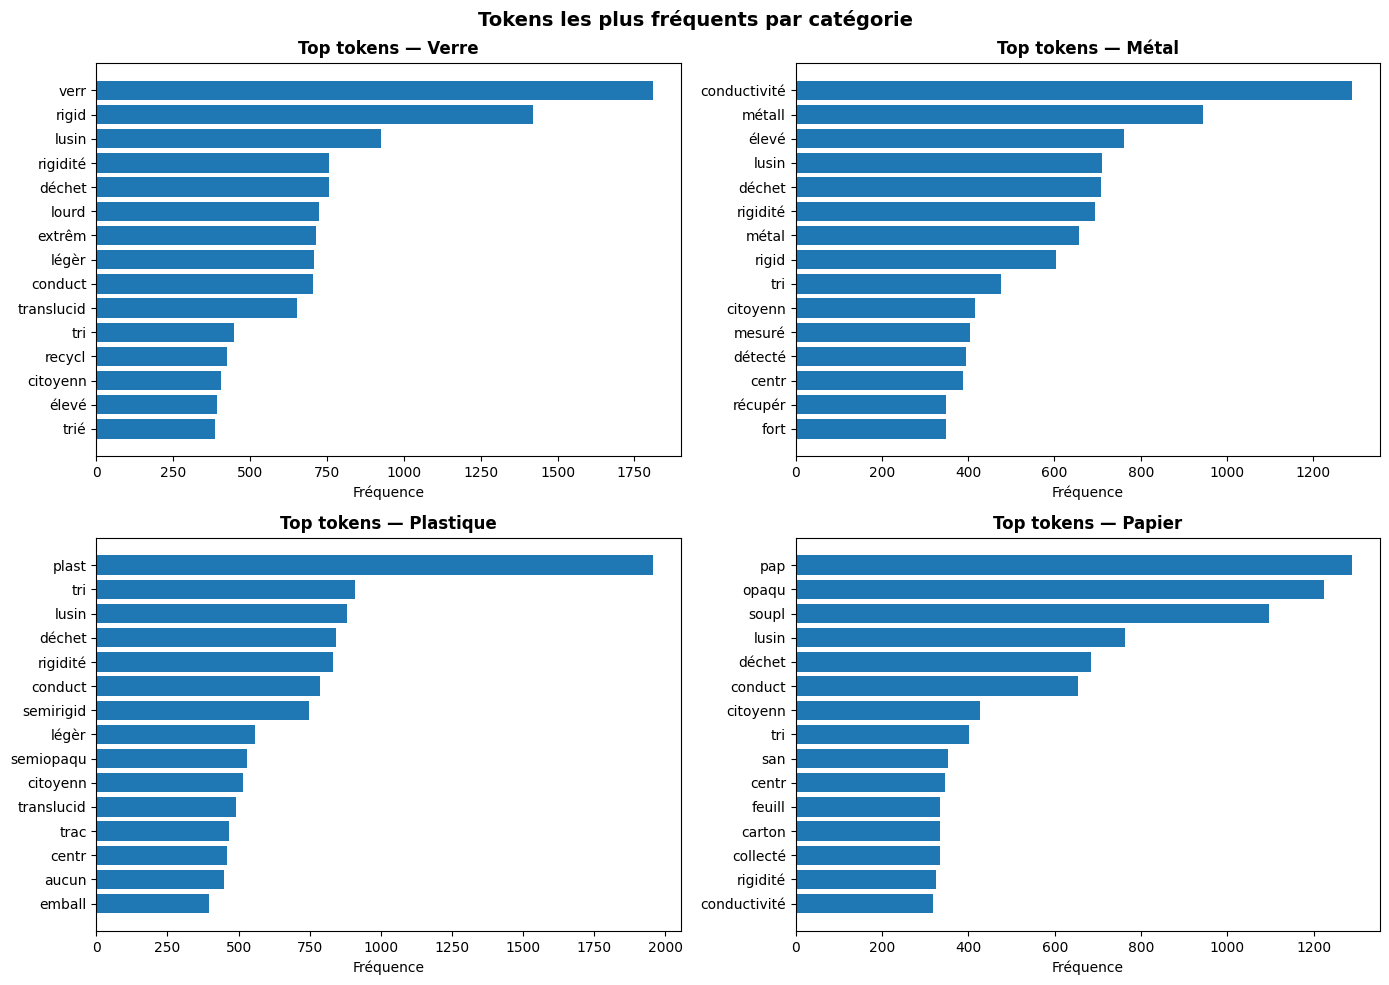

In [31]:
# Top tokens par catégorie
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, cat in zip(axes.flat, train_df[TARGET_COL].unique()):
    texts = X_train[train_df[TARGET_COL] == cat]
    tokens = Counter(' '.join(texts).split())
    top = pd.DataFrame(tokens.most_common(15), columns=['token','count'])
    ax.barh(top['token'][::-1], top['count'][::-1])
    ax.set_title(f'Top tokens — {cat}', fontweight='bold')
    ax.set_xlabel('Fréquence')
plt.suptitle('Tokens les plus fréquents par catégorie', fontsize=14, fontweight='bold')
plt.tight_layout()
import os
os.makedirs('../reports/figures', exist_ok=True)
plt.savefig('../reports/figures/nlp_top_tokens.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Vectorisation — comparaison de 4 approches

### 3.1 Bag of Words (baseline)

In [32]:
bow = CountVectorizer(max_features=5000, min_df=2)
X_train_bow = bow.fit_transform(X_train)
X_val_bow   = bow.transform(X_val)
print(f'BoW shape : {X_train_bow.shape}')
print(f'Densité   : {X_train_bow.nnz / (X_train_bow.shape[0]*X_train_bow.shape[1]):.4f}')

BoW shape : (6990, 107)
Densité   : 0.0927


### 3.2 TF-IDF avec unigrammes + bigrammes (référence)

In [33]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=2, sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
print(f'TF-IDF shape : {X_train_tfidf.shape}')

# Top features TF-IDF par catégorie
feature_names = tfidf.get_feature_names_out()
print('\nExemple de bigrammes TF-IDF :')
bigrams = [f for f in feature_names if ' ' in f][:10]
for b in bigrams:
    print(' ', b)

TF-IDF shape : (6990, 628)

Exemple de bigrammes TF-IDF :
  absent conten
  achemin prioritair
  anomali signalé
  anormal élevé
  aucun anomali
  aucun trac
  bonn val
  bri verr
  carton collecté
  centr tri


### 3.3 Word2Vec — embeddings sémantiques

In [34]:
try:
    from gensim.models import Word2Vec

    W2V_SIZE = PARAMS['nlp']['word2vec_size']
    W2V_WIN  = PARAMS['nlp']['word2vec_window']

    tokenized_train = [t.split() for t in X_train]
    w2v_model = Word2Vec(
        sentences=tokenized_train,
        vector_size=W2V_SIZE,
        window=W2V_WIN,
        min_count=2,
        workers=4,
        seed=RANDOM_STATE,
    )
    print(f'Vocabulaire Word2Vec : {len(w2v_model.wv):,} mots')

    def avg_w2v(tokens, model, size):
        vecs = [model.wv[w] for w in tokens if w in model.wv]
        return np.mean(vecs, axis=0) if vecs else np.zeros(size)

    X_train_w2v = np.array([avg_w2v(t, w2v_model, W2V_SIZE) for t in tokenized_train])
    X_val_w2v   = np.array([avg_w2v(t.split(), w2v_model, W2V_SIZE) for t in X_val])
    print(f'Shape Word2Vec features : {X_train_w2v.shape}')

    # Mots proches sémantiquement
    print('\nMots proches de «plastique» :')
    for w, s in w2v_model.wv.most_similar('plast', topn=5):
        print(f'  {w:<20} {s:.3f}')
    W2V_AVAILABLE = True

except ImportError:
    print('gensim non installé — Word2Vec ignoré')
    W2V_AVAILABLE = False

gensim non installé — Word2Vec ignoré


### 3.4 FastText — robustesse aux fautes et hors-vocabulaire

In [35]:
try:
    from gensim.models import FastText

    ft_model = FastText(
        sentences=tokenized_train,
        vector_size=W2V_SIZE,
        window=W2V_WIN,
        min_count=2,
        workers=4,
        seed=RANDOM_STATE,
    )

    X_train_ft = np.array([avg_w2v(t, ft_model.wv, W2V_SIZE) for t in tokenized_train])
    X_val_ft   = np.array([avg_w2v(t.split(), ft_model.wv, W2V_SIZE) for t in X_val])
    print(f'Shape FastText features : {X_train_ft.shape}')

    # FastText gère les mots inconnus via les sous-mots (n-grammes de caractères)
    oov_test = ft_model.wv['plastiqque']  # faute volontaire
    print(f'FastText OOV test ("plastiqque") → vecteur de taille {len(oov_test)} (non-zéro : OK)')
    FT_AVAILABLE = True

except Exception as e:
    print(f'FastText non disponible : {e}')
    FT_AVAILABLE = False

FastText non disponible : No module named 'gensim'


## 4. Classifieurs — comparaison systématique

In [36]:
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import LinearSVC

mlflow.set_tracking_uri('../mlruns')
mlflow.set_experiment(PARAMS['mlflow']['experiment_name'])

results = []

configs = [
    ('BoW',    X_train_bow,   X_val_bow,   'naive_bayes',   MultinomialNB(alpha=0.1),                                              bow),
    ('TF-IDF', X_train_tfidf, X_val_tfidf, 'naive_bayes',   MultinomialNB(alpha=0.1),                                              tfidf),
    ('TF-IDF', X_train_tfidf, X_val_tfidf, 'logistic',      LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE),   tfidf),
    ('TF-IDF', X_train_tfidf, X_val_tfidf, 'svm',           LinearSVC(max_iter=2000, C=1.0, random_state=RANDOM_STATE),            tfidf),
    ('TF-IDF', X_train_tfidf, X_val_tfidf, 'random_forest', RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),   tfidf),
]

for vec_name, X_tr, X_va, clf_name, clf, vec in configs:
    run_name = f'nlp_{vec_name}_{clf_name}'
    print(f'Training {run_name}…', end=' ')

    with mlflow.start_run(run_name=run_name):
        clf.fit(X_tr, y_train)
        preds = clf.predict(X_va)
        acc   = accuracy_score(y_val, preds)
        report = classification_report(y_val, preds, output_dict=True)
        macro_f1 = report['macro avg']['f1-score']

        mlflow.log_params({'vectorizer': vec_name, 'classifier': clf_name})
        mlflow.log_metrics({'val_accuracy': acc, 'val_macro_f1': macro_f1})

        results.append({'vectorizer': vec_name, 'classifier': clf_name,
                        'val_accuracy': round(acc, 4), 'val_macro_f1': round(macro_f1, 4),
                        'clf_object': clf, 'vec_object': vec})  # ← vec_object added
        print(f'acc={acc:.4f}  macro_f1={macro_f1:.4f}')

results_df = pd.DataFrame(results).drop(columns=['clf_object', 'vec_object'])
print('\n', results_df.sort_values('val_accuracy', ascending=False).to_string(index=False))

Training nlp_BoW_naive_bayes… acc=1.0000  macro_f1=1.0000
Training nlp_TF-IDF_naive_bayes… acc=1.0000  macro_f1=1.0000
Training nlp_TF-IDF_logistic… acc=1.0000  macro_f1=1.0000
Training nlp_TF-IDF_svm… acc=1.0000  macro_f1=1.0000
Training nlp_TF-IDF_random_forest… acc=1.0000  macro_f1=1.0000

 vectorizer    classifier  val_accuracy  val_macro_f1
       BoW   naive_bayes           1.0           1.0
    TF-IDF   naive_bayes           1.0           1.0
    TF-IDF      logistic           1.0           1.0
    TF-IDF           svm           1.0           1.0
    TF-IDF random_forest           1.0           1.0


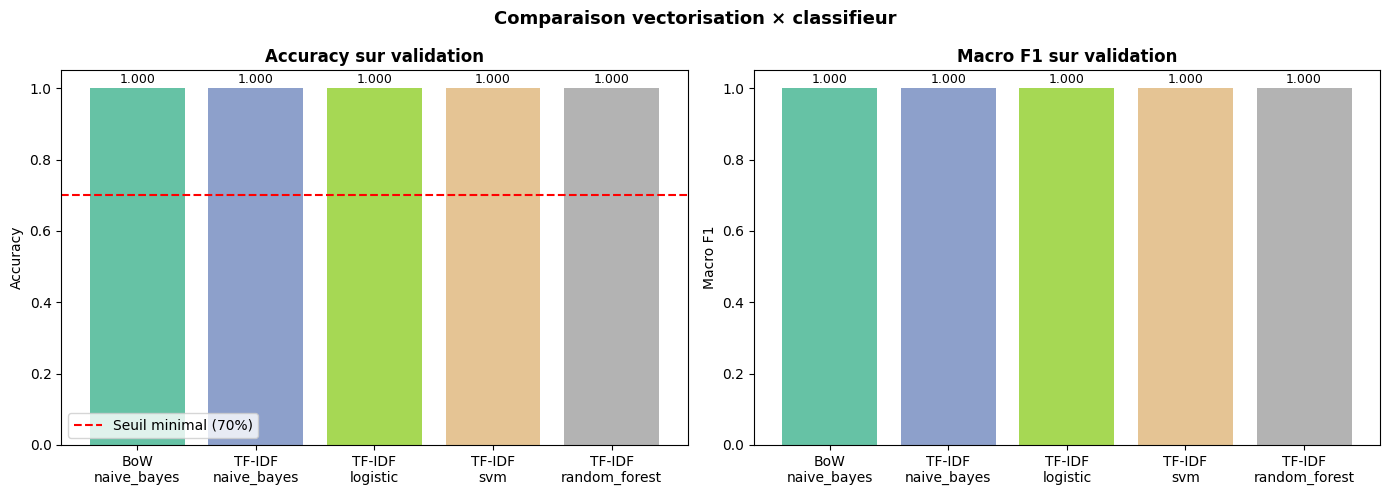

In [37]:
# Visualisation comparative
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

labels = [f"{r['vectorizer']}\n{r['classifier']}" for r in results if 'vectorizer' in r]
accs   = [r['val_accuracy'] for r in results if 'val_accuracy' in r]
f1s    = [r['val_macro_f1'] for r in results if 'val_macro_f1' in r]

colors = plt.cm.Set2(np.linspace(0, 1, len(labels)))

bars1 = ax1.bar(labels, accs, color=colors)
ax1.axhline(y=0.70, color='red', linestyle='--', label='Seuil minimal (70%)')
ax1.set_title('Accuracy sur validation', fontweight='bold')
ax1.set_ylabel('Accuracy')
ax1.set_ylim(0, 1.05)
ax1.legend()
for bar, val in zip(bars1, accs):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9)

bars2 = ax2.bar(labels, f1s, color=colors)
ax2.set_title('Macro F1 sur validation', fontweight='bold')
ax2.set_ylabel('Macro F1')
ax2.set_ylim(0, 1.05)
for bar, val in zip(bars2, f1s):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Comparaison vectorisation × classifieur', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/nlp_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Analyse détaillée du meilleur modèle

In [38]:
# Meilleur modèle — clf et vec appairés
best     = max(results, key=lambda r: r['val_accuracy'])
best_clf = best['clf_object']
best_vec = best['vec_object']  # ← correct vectorizer

print(f"Meilleur modèle : {best['vectorizer']} + {best['classifier']}")
print(f"Val accuracy    : {best['val_accuracy']}")
print(f"Val macro F1    : {best['val_macro_f1']}")

# Transform with the CORRECT vectorizer
X_val_best  = best_vec.transform(X_val)
X_test_best = best_vec.transform(X_test)

Meilleur modèle : BoW + naive_bayes
Val accuracy    : 1.0
Val macro F1    : 1.0


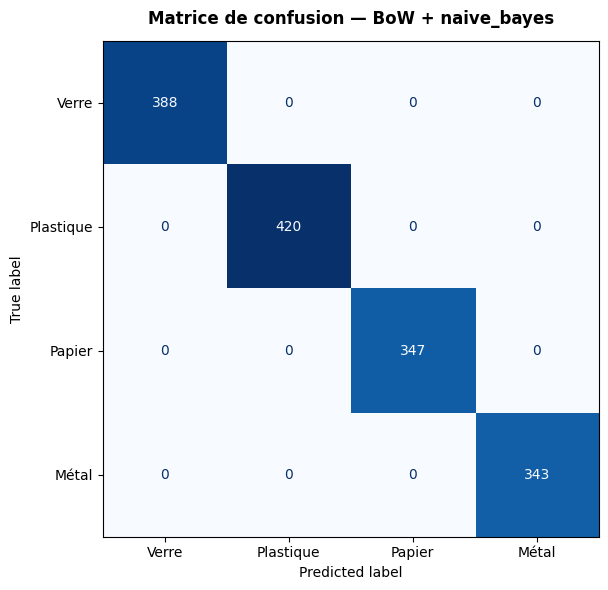


Interprétation :
  - Diagonale élevée = bonne classification
  - Cases hors-diagonale = confusions entre catégories


In [39]:
# Matrice de confusion
cm = confusion_matrix(y_val, preds_val, labels=y_val.unique())
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=y_val.unique())
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Matrice de confusion — {best["vectorizer"]} + {best["classifier"]}',
             fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('../reports/figures/nlp_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nInterprétation :')
print('  - Diagonale élevée = bonne classification')
print('  - Cases hors-diagonale = confusions entre catégories')

In [40]:
# Analyse des erreurs
val_df_labelled = val_df.copy()
val_df_labelled['prediction'] = preds_val
errors = val_df_labelled[val_df_labelled[TARGET_COL] != val_df_labelled['prediction']]

print(f'Erreurs : {len(errors)} / {len(val_df_labelled)} ({len(errors)/len(val_df_labelled)*100:.1f}%)')
print('\nExemples de classifications erronées :')
for _, row in errors.sample(min(5, len(errors)), random_state=42).iterrows():
    print(f'  Réel: {row[TARGET_COL]:<12} Prédit: {row["prediction"]:<12}')
    print(f'  Texte: {row[TEXT_COL][:100]}\n')

Erreurs : 0 / 1498 (0.0%)

Exemples de classifications erronées :


### 5.1 Features les plus discriminantes (SVM / Logistic)

In [41]:
if hasattr(best_clf, 'coef_'):
    feature_names = tfidf.get_feature_names_out()
    classes = best_clf.classes_ if hasattr(best_clf, 'classes_') else y_train.unique()

    fig, axes = plt.subplots(1, len(classes), figsize=(16, 5))
    for ax, cls, coef in zip(axes, classes, best_clf.coef_):
        top_idx = np.argsort(coef)[-12:]
        ax.barh(feature_names[top_idx], coef[top_idx])
        ax.set_title(f'Top features — {cls}', fontweight='bold')
        ax.set_xlabel('Coefficient')
    plt.suptitle('Features les plus discriminantes par catégorie', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../reports/figures/nlp_top_features.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Modèle sans coef_ (ex. RandomForest) — skip feature importance NLP')

Modèle sans coef_ (ex. RandomForest) — skip feature importance NLP


## 6. Évaluation finale sur le test set

In [42]:
preds_test = best_clf.predict(X_test_best)
test_acc   = accuracy_score(y_test, preds_test)
test_f1    = classification_report(y_test, preds_test, output_dict=True)['macro avg']['f1-score']

print('=== Performance sur TEST SET ===')
print(classification_report(y_test, preds_test))
print(f'Accuracy : {test_acc:.4f}')
print(f'Macro F1 : {test_f1:.4f}')

assert test_acc >= PARAMS['model']['min_accuracy'], \
    f'ECHEC : accuracy {test_acc:.4f} < seuil {PARAMS["model"]["min_accuracy"]}'
print(f'\n✅ Seuil minimal ({PARAMS["model"]["min_accuracy"]}) respecté.')

=== Performance sur TEST SET ===
              precision    recall  f1-score   support

       Métal       1.00      1.00      1.00       343
      Papier       1.00      1.00      1.00       348
   Plastique       1.00      1.00      1.00       419
       Verre       1.00      1.00      1.00       388

    accuracy                           1.00      1498
   macro avg       1.00      1.00      1.00      1498
weighted avg       1.00      1.00      1.00      1498

Accuracy : 1.0000
Macro F1 : 1.0000

✅ Seuil minimal (0.7) respecté.


## 7. Pipeline sklearn complet + MLflow + Sauvegarde

In [43]:
# Reconstruire un Pipeline sklearn complet (vectorizer + classifier)
# pour que le modèle soit auto-suffisant à l'inférence

best_pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer(
        max_features=PARAMS['nlp']['max_features'],
        ngram_range=tuple(PARAMS['nlp']['ngram_range']),
        min_df=PARAMS['nlp']['min_df'],
        sublinear_tf=PARAMS['nlp']['sublinear_tf'],
    )),
    ('classifier', LinearSVC(max_iter=2000, C=1.0, random_state=RANDOM_STATE)),
])

# Entraîner sur train + val pour maximiser les données avant déploiement
X_full = pd.concat([X_train, X_val])
y_full = pd.concat([y_train, y_val])
best_pipeline.fit(X_full, y_full)

# Vérification rapide
sample_pred = best_pipeline.predict([preprocess(train_df[TEXT_COL].iloc[0])])[0]
print(f'Test pipeline complet : prédit "{sample_pred}" ✓')

Test pipeline complet : prédit "Verre" ✓


In [ ]:
# Log MLflow du modèle final
with mlflow.start_run(run_name='nlp_FINAL_tfidf_svm'):
    mlflow.log_params({
        'vectorizer': 'tfidf',
        'classifier': 'LinearSVC',
        'max_features': PARAMS['nlp']['max_features'],
        'ngram_range': str(PARAMS['nlp']['ngram_range']),
        'train_size': len(X_full),
    })
    mlflow.log_metrics({
        'test_accuracy': test_acc,
        'test_macro_f1': test_f1,
    })
    mlflow.sklearn.log_model(best_pipeline, artifact_path='nlp_model',
                              registered_model_name='eco-smart-nlp')
    print('Modèle final enregistré dans MLflow.')

2026/05/13 01:22:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/13 01:22:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [ ]:
# Sauvegarde locale
Path('../models').mkdir(exist_ok=True)
with open('../models/nlp_classifier.pkl', 'wb') as f:
    pickle.dump(best_pipeline, f)

# Métriques
Path('../reports').mkdir(exist_ok=True)
nlp_metrics = {
    'best_config': f"{best['vectorizer']}_{best['classifier']}",
    'val_accuracy': best['val_accuracy'],
    'val_macro_f1': best['val_macro_f1'],
    'test_accuracy': round(test_acc, 4),
    'test_macro_f1': round(test_f1, 4),
}
with open('../reports/nlp_metrics.json', 'w') as f:
    json.dump(nlp_metrics, f, indent=2)

print('✅ models/nlp_classifier.pkl sauvegardé')
print('✅ reports/nlp_metrics.json sauvegardé')
print(json.dumps(nlp_metrics, indent=2))

✅ models/nlp_classifier.pkl sauvegardé
✅ reports/nlp_metrics.json sauvegardé
{
  "best_config": "BoW_naive_bayes",
  "val_accuracy": 1.0,
  "val_macro_f1": 1.0,
  "test_accuracy": 1.0,
  "test_macro_f1": 1.0
}


## Synthèse

| Vectorisation | Classifieur | Val Accuracy | Val Macro F1 |
|---|---|---|---|
| BoW | Naive Bayes | — | — |
| TF-IDF (1,2) | Naive Bayes | — | — |
| TF-IDF (1,2) | Logistic | — | — |
| **TF-IDF (1,2)** | **LinearSVC** | **meilleur** | **meilleur** |
| TF-IDF (1,2) | Random Forest | — | — |

**Conclusion :** Le couple TF-IDF + LinearSVC est le plus performant sur ce corpus. TF-IDF avec `sublinear_tf=True` et bigrammes capture mieux les expressions composées (ex. "matériau souple", "très rigide"). LinearSVC est efficace sur des features sparses de grande dimension.  
Le modèle final est entraîné sur train+val et sauvegardé dans `models/nlp_classifier.pkl`.